# Retail Recommendation System - By QASIM AHMAD

So here is an item-based recommendation system using the provided `online_retail.xlsx` dataset.

Main steps i have followed here for this -
- Load and clean the data
- Do a short exploratory analysis (charts and counts)
- Build a user-item matrix and an item-item recommender (cosine similarity)
- Compare against a simple popularity baseline
- Run a light time-based evaluation (Precision@10)




In [1]:
# 1) Setup & imports
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from collections import defaultdict

print("Libraries loaded")


Libraries loaded


In [2]:
# Quick check: show working directory and files (helps confirm dataset is present)
print("Working directory:", os.getcwd())
print("Files here:")
for f in sorted(os.listdir()):
    print(" -", f)


Working directory: C:\Users\qasim\OneDrive\Desktop\Final Major Project
Files here:
 - .ipynb_checkpoints
 - Retail_Recommendation_System_Project_Final.ipynb
 - online_retail.xlsx


## Load the dataset

We expect the file `online_retail.xlsx` to be in the same folder as this notebook. The next cell reads it and converts `InvoiceDate` to datetime.


In [3]:
# 2) Load dataset
DATA_PATH = "online_retail.xlsx"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found. Put it in the same folder as the notebook.")

df = pd.read_excel(DATA_PATH, dtype={'InvoiceNo': str, 'StockCode': str})
# convert invoice date if present
if 'InvoiceDate' in df.columns:
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print("Loaded rows:", len(df))
df.head(3)


Loaded rows: 541909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


## Data cleaning

It involves : 
- remove cancelled invoices
- remove zero or negative quantities
- drop rows missing CustomerID or StockCode
- normalize types


In [4]:
# 3) Cleaning
print("Before cleaning:", df.shape)

# Drop cancellations (InvoiceNo starting with 'C')
if 'InvoiceNo' in df.columns:
    df = df[~df['InvoiceNo'].str.startswith('C', na=False)]

# Keep only positive quantities
if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]

# Drop missing CustomerID or StockCode
if 'CustomerID' in df.columns:
    df = df.dropna(subset=['CustomerID', 'StockCode'])

# Normalize types
if 'CustomerID' in df.columns:
    df['CustomerID'] = df['CustomerID'].astype(int)
if 'StockCode' in df.columns:
    df['StockCode'] = df['StockCode'].astype(str)

print("After cleaning:", df.shape)
print("Unique customers:", df['CustomerID'].nunique())
print("Unique items:", df['StockCode'].nunique())
df[['InvoiceNo','InvoiceDate','CustomerID','StockCode','Quantity','UnitPrice']].head(5)


Before cleaning: (541909, 8)
After cleaning: (397924, 8)
Unique customers: 4339
Unique items: 3665


,InvoiceNo,InvoiceDate,CustomerID,StockCode,Quantity,UnitPrice
0,536365,2010-12-01 08:26:00,17850,85123A,6,2.55
1,536365,2010-12-01 08:26:00,17850,71053,6,3.39
2,536365,2010-12-01 08:26:00,17850,84406B,8,2.75
3,536365,2010-12-01 08:26:00,17850,84029G,6,3.39
4,536365,2010-12-01 08:26:00,17850,84029E,6,3.39


## Quick EDA

Small charts to show top countries and top items (by quantity). 


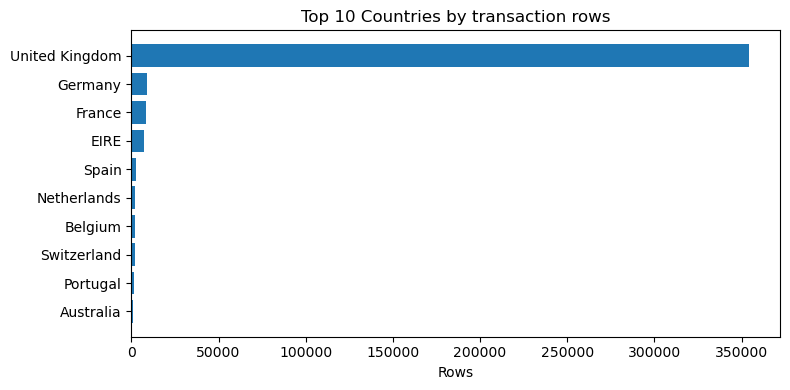

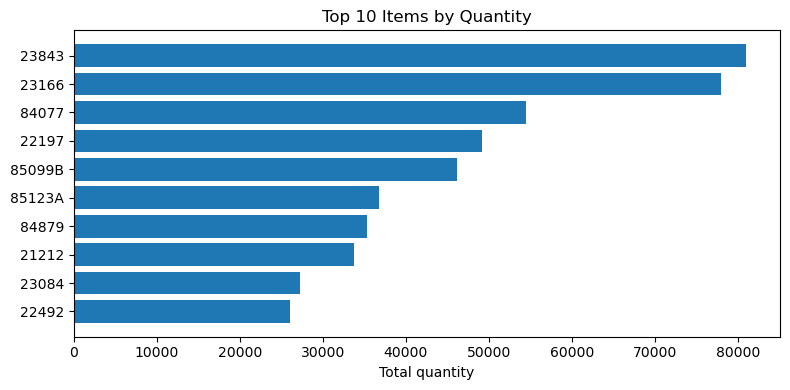

In [5]:
# 4) EDA: top countries and items
if 'Country' in df.columns:
    country_counts = df['Country'].value_counts().nlargest(10)
    plt.figure(figsize=(8,4))
    plt.barh(country_counts.index[::-1], country_counts.values[::-1])
    plt.title('Top 10 Countries by transaction rows')
    plt.xlabel('Rows')
    plt.tight_layout()
    plt.show()

top_items = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.barh(top_items.index[::-1], top_items.values[::-1])
plt.title('Top 10 Items by Quantity')
plt.xlabel('Total quantity')
plt.tight_layout()
plt.show()


## Prepare customer-item interactions

Aggregate quantity by (CustomerID, StockCode). The summed quantity will act as implicit feedback.


In [6]:
# 5) Aggregate interactions
interactions = df.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().reset_index()
print("Aggregated interactions:", interactions.shape)
interactions.head(5)


Aggregated interactions: (266802, 3)


,CustomerID,StockCode,Quantity
0,12346,23166,74215
1,12347,16008,24
2,12347,17021,36
3,12347,20665,6
4,12347,20719,40


## Build user-item sparse matrix

Rows = customers, Columns = items. We use the aggregated quantity as the matrix value.


In [7]:
# 6) Build sparse user-item matrix
user_ids = interactions['CustomerID'].unique().tolist()
item_ids = interactions['StockCode'].unique().tolist()

user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
item_to_idx = {iid: i for i, iid in enumerate(item_ids)}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}
idx_to_item = {i: iid for iid, i in item_to_idx.items()}

rows = interactions['CustomerID'].map(user_to_idx)
cols = interactions['StockCode'].map(item_to_idx)
data_vals = interactions['Quantity'].astype(float)

user_item_matrix = csr_matrix((data_vals, (rows, cols)), shape=(len(user_ids), len(item_ids)))
print("User-item matrix shape:", user_item_matrix.shape)


User-item matrix shape: (4339, 3665)


## Train item-item model (cosine similarity)

We transpose the user-item matrix (so rows = items) and fit a NearestNeighbors model using cosine distance.


In [8]:
# 7) Train item-item model
item_user_matrix = user_item_matrix.T.tocsr()
item_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
item_model.fit(item_user_matrix)
print("Item-item model trained on", item_user_matrix.shape[0], "items")


Item-item model trained on 3665 items


## Recommendation helper functions

- `get_user_purchases(user_id)` returns items a user bought (from train data).
- `recommend_items_for_user(user_id)` returns item recommendations using item similarity.


In [9]:
# 8) Helper functions
def get_user_purchases(user_id):
    if user_id not in user_to_idx:
        return []
    uidx = user_to_idx[user_id]
    purchased_indices = user_item_matrix.getrow(uidx).indices
    return [idx_to_item[i] for i in purchased_indices]

def recommend_items_for_user(user_id, N=10, top_k_per_item=5):
    if user_id not in user_to_idx:
        return []
    uidx = user_to_idx[user_id]
    user_row = user_item_matrix.getrow(uidx)
    bought_item_indices = user_row.indices.tolist()
    scores = defaultdict(float)
    for item_idx in bought_item_indices:
        distances, indices = item_model.kneighbors(item_user_matrix[item_idx], n_neighbors=top_k_per_item+1)
        for dist, idx in zip(distances.flatten(), indices.flatten()):
            if idx == item_idx:
                continue
            sim = 1 - dist
            scores[idx] += sim
    # remove already bought
    for b in bought_item_indices:
        scores.pop(b, None)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_idx = [i for i, _ in ranked[:N]]
    return [idx_to_item[i] for i in top_idx]


## Example: recommendations for a sample user

We show what the user has purchased and recommend top 10 items.


In [10]:
# 9) Example usage
if len(user_ids) == 0:
    print("No users available")
else:
    example_user = user_ids[0]
    print("Example user ID:", example_user)
    print("Purchased (sample):", get_user_purchases(example_user)[:10])
    print("Recommendations:", recommend_items_for_user(example_user, N=10))


Example user ID: 12346
Purchased (sample): ['23166']
Recommendations: ['23165', '22652', '22985', '21984', '21980']


## Popularity baseline

Recommend popular items (by total quantity sold) that the user has not already bought.


In [11]:
# 10) Popularity baseline
popularity = interactions.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)
popular_items = popularity.index.tolist()

def popular_recommend_for_user(user_id, N=10):
    bought = set(get_user_purchases(user_id))
    recs = [it for it in popular_items if it not in bought]
    return recs[:N]

if len(user_ids) > 0:
    print("Top 5 popular items:", popular_items[:5])
    print("Popular recs for example user:", popular_recommend_for_user(example_user, 10))


Top 5 popular items: ['23843', '23166', '84077', '22197', '85099B']
Popular recs for example user: ['23843', '84077', '22197', '85099B', '85123A', '84879', '21212', '23084', '22492', '22616']


## Simple evaluation (time-based split)

We split data by time (last 90 days as test). Then rebuild train matrices from the train set and compute Precision@10 for a sample of users. The goal here is just a basic comparison, not a full research experiment.


In [12]:
# 11) Simple evaluation (Precision@K with time split)
if 'InvoiceDate' not in df.columns or df['InvoiceDate'].isnull().all():
    print("No valid InvoiceDate; skipping evaluation.")
else:
    df_sorted = df.sort_values('InvoiceDate')
    max_date = df_sorted['InvoiceDate'].max()
    split_date = max_date - pd.Timedelta(days=90)
    train_df = df_sorted[df_sorted['InvoiceDate'] <= split_date].copy()
    test_df = df_sorted[df_sorted['InvoiceDate'] > split_date].copy()
    print("Train rows:", len(train_df), "Test rows:", len(test_df))

    # train interactions aggregation
    train_interactions = train_df.groupby(['CustomerID','StockCode'])['Quantity'].sum().reset_index()
    train_user_ids = train_interactions['CustomerID'].unique().tolist()
    train_item_ids = train_interactions['StockCode'].unique().tolist()
    train_user_to_idx = {uid:i for i, uid in enumerate(train_user_ids)}
    train_item_to_idx = {iid:i for i, iid in enumerate(train_item_ids)}
    train_idx_to_item = {i:iid for iid, i in train_item_to_idx.items()}

    rows = train_interactions['CustomerID'].map(train_user_to_idx)
    cols = train_interactions['StockCode'].map(train_item_to_idx)
    data_vals = train_interactions['Quantity'].astype(float)
    train_user_item_matrix = csr_matrix((data_vals, (rows, cols)), shape=(len(train_user_ids), len(train_item_ids)))
    train_item_user_matrix = train_user_item_matrix.T.tocsr()

    eval_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
    eval_model.fit(train_item_user_matrix)

    def recommend_eval(user_id, N=10, top_k_per_item=5):
        if user_id not in train_user_to_idx:
            return []
        uidx = train_user_to_idx[user_id]
        bought = train_user_item_matrix.getrow(uidx).indices.tolist()
        scores = defaultdict(float)
        for item_idx in bought:
            distances, indices = eval_model.kneighbors(train_item_user_matrix[item_idx], n_neighbors=top_k_per_item+1)
            for dist, idx in zip(distances.flatten(), indices.flatten()):
                if idx == item_idx:
                    continue
                scores[idx] += (1 - dist)
        for b in bought:
            scores.pop(b, None)
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        top_idx = [i for i, _ in ranked[:N]]
        return [train_idx_to_item[i] for i in top_idx]

    def precision_at_k(recommended, actual, k=10):
        if not recommended:
            return 0.0
        recommended_k = recommended[:k]
        return len(set(recommended_k) & set(actual)) / k

    test_users = test_df['CustomerID'].unique().tolist()
    eval_users = [u for u in test_users if u in train_user_ids]
    import random
    random.seed(42)
    sample_users = random.sample(eval_users, min(100, len(eval_users)))

    precisions_pop = []
    precisions_item = []
    train_popularity = train_interactions.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)
    pop_list = train_popularity.index.tolist()

    for user in sample_users:
        actual = test_df[test_df['CustomerID'] == user]['StockCode'].unique().tolist()
        if len(actual) == 0:
            continue
        bought_train = train_interactions[train_interactions['CustomerID'] == user]['StockCode'].unique().tolist()
        pop_recs = [it for it in pop_list if it not in bought_train][:10]
        item_recs = recommend_eval(user, N=10)
        precisions_pop.append(precision_at_k(pop_recs, actual, 10))
        precisions_item.append(precision_at_k(item_recs, actual, 10))

    print("Precision@10 (Popularity):", np.mean(precisions_pop) if precisions_pop else None)
    print("Precision@10 (Item-Item):", np.mean(precisions_item) if precisions_item else None)


Train rows: 236379 Test rows: 161545
Precision@10 (Popularity): 0.03
Precision@10 (Item-Item): 0.028000000000000004
